# BREED Ionic Conductivity — Data Loading & Cleaning

**Goal**: Combine OBELiX and Liverpool datasets into a clean training pool, keeping OBELiX test set completely separate.

**Files needed in this directory:**
- `obelix_train.csv` — OBELiX training split (478 entries)  
- `obelix_test.csv` — OBELiX test split (121 entries) ⚠️ DO NOT TOUCH after saving
- `liverpool.csv` — Liverpool/npj dataset (820 entries)

Rename your files to match these names, or change the paths below.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)

In [38]:
# Load OBELiX train/test
ob_train = pd.read_csv('raw_data/obelix_train.csv')
ob_test = pd.read_csv('raw_data/obelix_test.csv')

# Load Liverpool (skip the 4 header lines of licensing text)
liv = pd.read_csv('raw_data/liverpool.csv', skiprows=4, encoding='utf-8-sig')

print(f"OBELiX train: {len(ob_train)} rows, {ob_train.shape[1]} cols")
print(f"OBELiX test:  {len(ob_test)} rows, {ob_test.shape[1]} cols")
print(f"Liverpool:    {len(liv)} rows, {liv.shape[1]} cols")

OBELiX train: 478 rows, 28 cols
OBELiX test:  121 rows, 28 cols
Liverpool:    820 rows, 8 cols


## Step 1: Inspect both datasets

In [39]:
# OBELiX columns we care about
print("=== OBELiX sample ===")
display(ob_train[['ID', 'Reduced Composition', 'Ionic conductivity (S cm-1)', 
                   'IC (Total)', 'IC (Bulk)', 'Space group #', 'Family', 'Liion ID']].head(10))

print("\n=== Liverpool sample ===")
display(liv.head(10))

=== OBELiX sample ===


,ID,Reduced Composition,Ionic conductivity (S cm-1),IC (Total),IC (Bulk),Space group #,Family,Liion ID
0,jqc,Li7BiO6,1.58489e-06,NaN,NaN,2,hexaoxometalates,NaN
1,oi6,Li7SbO6,6.7e-08,NaN,NaN,2,hexaoxometalates,NaN
2,2t8,LiV(PO4)F,8.1e-07,NaN,NaN,2,Tavorite,NaN
3,47i,Li4P2O7,<1E-10,NaN,NaN,2,diphosphate,NaN
4,clt,Li6CuB4O10,1e-13,NaN,NaN,2,copper pyroborate,NaN
5,ix1,Li0.91Hf2.022(PO4)3,3.2e-07,NaN,NaN,167,NASICON,NaN
6,bq9,Li3BiO3,2.4e-10,NaN,NaN,2,oxides,NaN
7,skm,Li5BiO5,3.9e-09,NaN,NaN,8,oxides,NaN
8,pwr,Li7.22Si1.5P0.5O8,1.64e-07,NaN,NaN,11,LISICON,NaN
9,b4c,Li4SiS4,1.59e-08,NaN,NaN,11,thio-LISICON,NaN



=== Liverpool sample ===


,ID,composition,source,temperature,target,log_target,family,ChemicalFamily
0,1,Li2Ti0.75Ta0.25O3.125,10.1016/j.fusengdes.2010.04.003,300.00,9.000000e-05,-4.045757,Rocksalt,Oxides
1,2,Li2OHBr,10.1002/aenm.201700971,22.06,5.400000e-07,-6.267606,Anti-Perovskite,Oxides and Other Anions
2,3,Li2.4OH0.6Cl,10.1002/aenm.201700971,26.00,8.900000e-08,-7.050610,Anti-Perovskite,Oxides and Other Anions
3,4,Li2.1OH0.9Cl,10.1002/aenm.201700971,26.00,8.050000e-08,-7.094204,Anti-Perovskite,Oxides and Other Anions
4,5,Li2OHCl,10.1002/aenm.201700971,26.00,7.110000e-08,-7.148130,Anti-Perovskite,Oxides and Other Anions
5,6,Li2.7OH0.3Cl,10.1002/aenm.201700971,26.00,7.300000e-09,-8.136677,Anti-Perovskite,Oxides and Other Anions
6,8,Li6PO5Cl,10.1002/zaac.201000121,25.00,1.000000e-09,-9.000000,Argyrodite,Oxides and Other Anions
7,14,Li14ZnGe4O16,10.1016/0025-5408(78)90075-2,300.00,1.250000e-01,-0.903090,LISICON,NaN
8,15,(YPO4)0.8(Li3PO4)0.2,10.1016/0167-2738(89)90457-8,600.00,3.700000e-02,-1.431798,Zircon,NaN
9,16,(YPO4)0.8(Li3PO4)0.2,10.1016/0167-2738(89)90457-8,400.00,5.400000e-04,-3.267606,Zircon,NaN


## Step 2: Clean OBELiX conductivity values

The `Ionic conductivity (S cm-1)` column has string entries like `<1E-10` and `<1E-8`. 
These are upper bounds — the actual conductivity is below that threshold. 

**Decision**: Replace `<1E-10` with `1E-10` and `<1E-8` with `1E-8` (treat as the bound value). 
These are very low conductivities that won't be competitive candidates anyway, but keeping them 
in training helps the model learn the low end of the distribution.

In [40]:
def clean_obelix_conductivity(df):
    """Clean conductivity column: handle '<1E-10' etc, convert to log scale."""
    df = df.copy()
    
    # Check what non-numeric values exist
    cond = df['Ionic conductivity (S cm-1)']
    non_numeric = cond[pd.to_numeric(cond, errors='coerce').isna()]
    print(f"Non-numeric conductivity values:\n{non_numeric.value_counts()}")
    
    # Replace upper bound strings with the bound value
    df['Ionic conductivity (S cm-1)'] = (
        df['Ionic conductivity (S cm-1)']
        .str.replace('<', '', regex=False)
    )
    df['conductivity_Scm'] = pd.to_numeric(df['Ionic conductivity (S cm-1)'], errors='coerce')
    
    # Log10 transform
    df['log_conductivity'] = np.log10(df['conductivity_Scm'])
    
    print(f"\nAfter cleaning: {df['log_conductivity'].isna().sum()} NaN values")
    print(f"Range: {df['log_conductivity'].min():.2f} to {df['log_conductivity'].max():.2f}")
    
    return df

ob_train = clean_obelix_conductivity(ob_train)
ob_test = clean_obelix_conductivity(ob_test)

Non-numeric conductivity values:
Ionic conductivity (S cm-1)
<1E-10    28
<1E-8      1
Name: count, dtype: int64

After cleaning: 0 NaN values
Range: -17.38 to -1.60
Non-numeric conductivity values:
Ionic conductivity (S cm-1)
<1E-10    8
Name: count, dtype: int64

After cleaning: 0 NaN values
Range: -17.36 to -1.60


## Step 3: Filter Liverpool to room temperature

Liverpool has measurements at many temperatures. OBELiX is all room temp.
We keep only entries measured between 15–35°C.

Note: Liverpool `temperature` column is in °C.

In [41]:
print(f"Liverpool total: {len(liv)}")
print(f"Temperature range: {liv['temperature'].min()} to {liv['temperature'].max()} °C")
print(f"\nDistribution:")
print(f"  < 15°C:  {(liv['temperature'] < 15).sum()}")
print(f"  15-35°C: {((liv['temperature'] >= 15) & (liv['temperature'] <= 35)).sum()}")
print(f"  > 35°C:  {(liv['temperature'] > 35).sum()}")

# Filter to room temperature
liv_rt = liv[(liv['temperature'] >= 15) & (liv['temperature'] <= 35)].copy()
print(f"\nKept {len(liv_rt)} room-temperature entries")

Liverpool total: 820
Temperature range: 5.0 to 873.0 °C

Distribution:
  < 15°C:  3
  15-35°C: 465
  > 35°C:  352

Kept 465 room-temperature entries


## Step 4: Deduplicate Liverpool against OBELiX

OBELiX has a `Liion ID` column that maps entries to Liverpool IDs. 
We remove any Liverpool entry that already exists in OBELiX (train OR test) to avoid data leakage.

In [42]:
# Get all Liverpool IDs that are already in OBELiX
ob_all = pd.concat([ob_train, ob_test])
liion_ids_in_obelix = set(ob_all['Liion ID'].dropna().astype(int))
print(f"Liverpool IDs already in OBELiX: {len(liion_ids_in_obelix)}")

# Remove them from Liverpool
liv_rt_new = liv_rt[~liv_rt['ID'].isin(liion_ids_in_obelix)].copy()
print(f"Liverpool entries removed (already in OBELiX): {len(liv_rt) - len(liv_rt_new)}")
print(f"Liverpool entries remaining: {len(liv_rt_new)}")

Liverpool IDs already in OBELiX: 144
Liverpool entries removed (already in OBELiX): 82
Liverpool entries remaining: 383


## Step 5: Standardize columns and combine

Create a unified dataframe with consistent column names. 
Key columns: `composition`, `log_conductivity`, `source`, `family`, `has_cif`

In [43]:
# --- Standardize OBELiX ---
def standardize_obelix(df, split_name):
    out = pd.DataFrame({
        'id': df['ID'],
        'composition': df['Reduced Composition'],
        'log_conductivity': df['log_conductivity'],
        'family': df['Family'],
        'space_group_num': df['Space group #'],
        'a': df['a'], 'b': df['b'], 'c': df['c'],
        'alpha': df['alpha'], 'beta': df['beta'], 'gamma': df['gamma'],
        'has_cif': df['Cif ID'].notna(),  # True if CIF exists
        'source': 'obelix',
        'split': split_name,
        'doi': df['DOI'],
    })
    return out

std_ob_train = standardize_obelix(ob_train, 'train')
std_ob_test = standardize_obelix(ob_test, 'test')

# --- Standardize Liverpool ---
def standardize_liverpool(df):
    out = pd.DataFrame({
        'id': 'liv_' + df['ID'].astype(str),  # prefix to avoid ID collisions
        'composition': df['composition'],
        'log_conductivity': df['log_target'],  # already in log10
        'family': df['family'],
        'space_group_num': np.nan,
        'a': np.nan, 'b': np.nan, 'c': np.nan,
        'alpha': np.nan, 'beta': np.nan, 'gamma': np.nan,
        'has_cif': False,
        'source': 'liverpool',
        'split': 'train',  # all Liverpool goes to train
        'doi': df['source'],  # Liverpool 'source' column is the DOI
    })
    return out

std_liv = standardize_liverpool(liv_rt_new)

print(f"Standardized OBELiX train: {len(std_ob_train)}")
print(f"Standardized OBELiX test:  {len(std_ob_test)}")
print(f"Standardized Liverpool:    {len(std_liv)}")

Standardized OBELiX train: 478
Standardized OBELiX test:  121
Standardized Liverpool:    383


In [44]:
# Combine training pool
train_pool = pd.concat([std_ob_train, std_liv], ignore_index=True)
test_set = std_ob_test.copy()

print(f"=== FINAL DATASET SIZES ===")
print(f"Training pool: {len(train_pool)} entries")
print(f"  - OBELiX:    {(train_pool['source'] == 'obelix').sum()}")
print(f"  - Liverpool:  {(train_pool['source'] == 'liverpool').sum()}")
print(f"  - With CIFs:  {train_pool['has_cif'].sum()}")
print(f"  - No CIFs:    {(~train_pool['has_cif']).sum()}")
print(f"\nTest set: {len(test_set)} entries (OBELiX only, DO NOT TOUCH)")
print(f"  - With CIFs:  {test_set['has_cif'].sum()}")

=== FINAL DATASET SIZES ===
Training pool: 861 entries
  - OBELiX:    478
  - Liverpool:  383
  - With CIFs:  471
  - No CIFs:    390

Test set: 121 entries (OBELiX only, DO NOT TOUCH)
  - With CIFs:  119


## Step 6: Sanity check — conductivity distributions

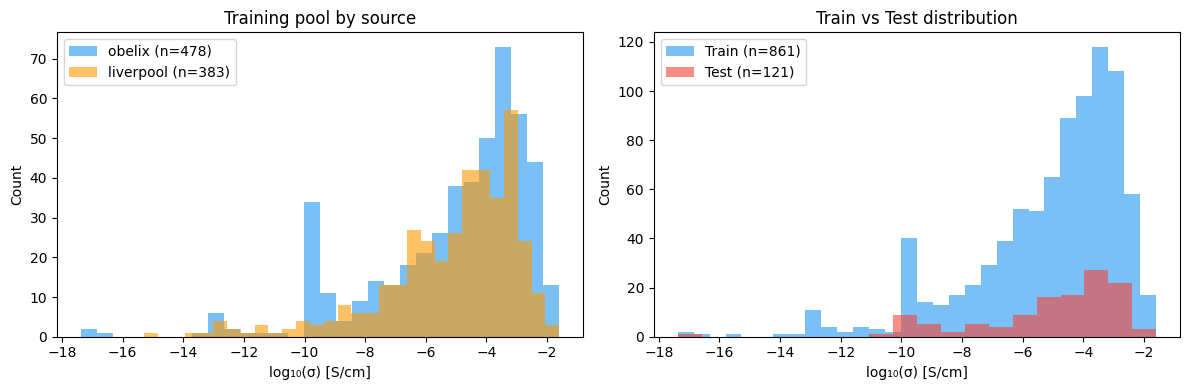

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training pool by source
for source, color in [('obelix', '#2196F3'), ('liverpool', '#FF9800')]:
    subset = train_pool[train_pool['source'] == source]
    axes[0].hist(subset['log_conductivity'], bins=30, alpha=0.6, 
                 label=f"{source} (n={len(subset)})", color=color)
axes[0].set_xlabel('log₁₀(σ) [S/cm]')
axes[0].set_ylabel('Count')
axes[0].set_title('Training pool by source')
axes[0].legend()

# Train vs test
axes[1].hist(train_pool['log_conductivity'], bins=30, alpha=0.6, 
             label=f"Train (n={len(train_pool)})", color='#2196F3')
axes[1].hist(test_set['log_conductivity'], bins=20, alpha=0.6, 
             label=f"Test (n={len(test_set)})", color='#f44336')
axes[1].set_xlabel('log₁₀(σ) [S/cm]')
axes[1].set_ylabel('Count')
axes[1].set_title('Train vs Test distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 7: Save clean datasets

These are your starting point for feature extraction.

In [46]:
# Save
train_pool.to_csv('clean_train.csv', index=False)
test_set.to_csv('clean_test_DO_NOT_TOUCH.csv', index=False)

print("Saved: clean_train.csv")
print("Saved: clean_test_DO_NOT_TOUCH.csv")
print("\n✓ Data loading and cleaning complete. Next step: feature extraction.")

Saved: clean_train.csv
Saved: clean_test_DO_NOT_TOUCH.csv

✓ Data loading and cleaning complete. Next step: feature extraction.
